# Módulo 7 — ARMA(p,q): selección de orden, sobre retornos y sobre precios

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.graphics.tsaplots as sgt
import statsmodels.tsa.stattools as sts
from statsmodels.tsa.arima.model import ARIMA
from scipy.stats.distributions import chi2
import warnings
warnings.filterwarnings("ignore")

def LLR_test(mod_1, mod_2, DF=1):
    L1 = mod_1.llf
    L2 = mod_2.llf
    LR = (2*(L2-L1))
    p = chi2.sf(LR, DF).round(3)
    return p

In [2]:
raw_csv_data = pd.read_csv("Index2018.csv")
df_comp = raw_csv_data.copy()
df_comp.date = pd.to_datetime(df_comp.date, dayfirst=True)
df_comp.set_index("date", inplace=True)
df_comp = df_comp.asfreq('B')
df_comp = df_comp.ffill()

df_comp['market_value'] = df_comp.ftse
del df_comp['spx']
del df_comp['dax']
del df_comp['ftse']
del df_comp['nikkei']
size = int(len(df_comp)*0.8)
df, df_test = df_comp.iloc[:size], df_comp.iloc[size:]
df['returns'] = df.market_value.pct_change(1)*100

## Escalera de órdenes ARMA(p,q) sobre retornos

In [3]:
ordenes = [(1, 1), (3, 3), (3, 2), (2, 3), (3, 1), (2, 2), (1, 3), (5, 5), (5, 1), (1, 5)]
ajustados = {}
for (p, q) in ordenes:
    modelo = ARIMA(df.returns[1:], order=(p, 0, q))
    ajustados[(p, q)] = modelo.fit()
    r = ajustados[(p, q)]
    print(f"ARMA({p},{q})  LL={r.llf:.3f}  AIC={r.aic:.3f}  BIC={r.bic:.3f}")

ARMA(1,1)  LL=-7916.500  AIC=15841.000  BIC=15867.085


ARMA(3,3)  LL=-7893.515  AIC=15803.030  BIC=15855.200


ARMA(3,2)  LL=-7895.747  AIC=15805.495  BIC=15851.143


ARMA(2,3)  LL=-7895.587  AIC=15805.175  BIC=15850.823


ARMA(3,1)  LL=-7899.072  AIC=15810.144  BIC=15849.271


ARMA(2,2)  LL=-7914.692  AIC=15841.384  BIC=15880.511


ARMA(1,3)  LL=-7896.838  AIC=15805.676  BIC=15844.803


ARMA(5,5)  LL=-7882.873  AIC=15789.747  BIC=15868.001


ARMA(5,1)  LL=-7889.311  AIC=15794.623  BIC=15846.792


ARMA(1,5)  LL=-7890.974  AIC=15797.949  BIC=15850.118


In [4]:
print("ARMA(1,1) vs ARMA(3,3), DF=4:", LLR_test(ajustados[(1, 1)], ajustados[(3, 3)], DF=4))
print("ARMA(3,1) vs ARMA(3,2):", LLR_test(ajustados[(3, 1)], ajustados[(3, 2)]))

ARMA(1,1) vs ARMA(3,3), DF=4: 0.0
ARMA(3,1) vs ARMA(3,2): 0.01


## El ganador: ARMA(5,1) — mejor BIC que ARMA(5,5), y muy cerca en AIC

In [5]:
df['res_ret_ar_5_ma_1'] = ajustados[(5, 1)].resid
print("media:", round(df.res_ret_ar_5_ma_1.mean(), 4), " varianza:", round(df.res_ret_ar_5_ma_1.var(), 4))
print("ADF residuos:", sts.adfuller(df.res_ret_ar_5_ma_1[1:]))

media: -0.0  varianza: 1.3573
ADF residuos: (-70.89287169064222, 0.0, 0, 5019, {'1%': np.float64(-3.4316535759402753), '5%': np.float64(-2.8621160400844468), '10%': np.float64(-2.567076626752987)}, np.float64(15697.239086846199))


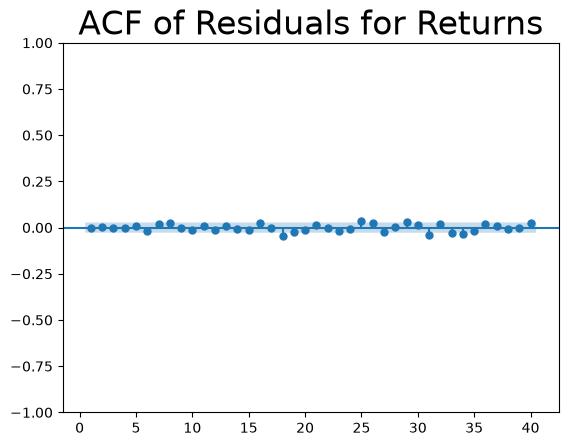

In [6]:
sgt.plot_acf(df.res_ret_ar_5_ma_1[1:], zero=False, lags=40)
plt.title("ACF of Residuals for Returns", size=24)
plt.show()

## ARMA sobre precios

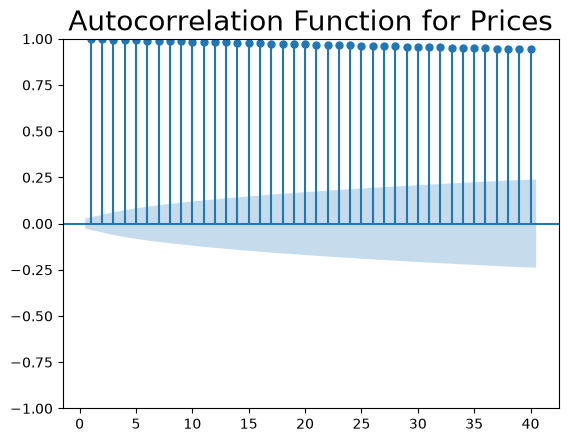

In [7]:
sgt.plot_acf(df.market_value, adjusted=True, zero=False, lags=40)
plt.title("Autocorrelation Function for Prices", size=20)
plt.show()

In [8]:
model_ar_1_ma_1_p = ARIMA(df.market_value, order=(1, 0, 1))
results_ar_1_ma_1_p = model_ar_1_ma_1_p.fit()
results_ar_1_ma_1_p.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:           market_value   No. Observations:                 5021
Model:                 ARIMA(1, 0, 1)   Log Likelihood              -27621.875
Date:                Wed, 16 Sep 2026   AIC                          55251.749
Time:                        18:55:46   BIC                          55277.835
Sample:                    01-07-1994   HQIC                         55260.890
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5089.6409    366.501     13.887      0.000    4371.312    5807.970
ar.L1          0.9982      0.001   1189.159      0.000       0.997       1.000
ma.L1         -0.0186      0.010     -1.894      0.058      -0.038       0.001
sigma2      3510.8350     41.068     85.489      0.000    3430.344    3591.326
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              3280.53
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):               1.89   Skew:                            -0.19
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.94
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [9]:
model_ar_6_ma_6_p = ARIMA(df.market_value, order=(6, 0, 6))
results_ar_6_ma_6_p = model_ar_6_ma_6_p.fit()
results_ar_6_ma_6_p.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:           market_value   No. Observations:                 5021
Model:                 ARIMA(6, 0, 6)   Log Likelihood              -27591.277
Date:                Wed, 16 Sep 2026   AIC                          55210.553
Time:                        18:55:49   BIC                          55301.853
Sample:                    01-07-1994   HQIC                         55242.546
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5089.6408    511.837      9.944      0.000    4086.459    6092.823
ar.L1          0.7381      0.926      0.797      0.425      -1.077       2.553
ar.L2          0.2445      1.554      0.157      0.875      -2.802       3.291
ar.L3         -0.4061      1.222     -0.332      0.740      -2.801       1.989
ar.L4          0.3422      0.758      0.451      0.652      -1.144       1.828
ar.L5         -0.1100      0.418     -0.263      0.792      -0.929       0.709
ar.L6          0.1891      0.254      0.746      0.456      -0.308       0.686
ma.L1          0.2406      0.926      0.260      0.795      -1.574       2.055
ma.L2         -0.0390      0.667     -0.058      0.953      -1.347       1.269
ma.L3          0.3344      0.562      0.595      0.552      -0.767       1.436
ma.L4          0.0823      0.243      0.339      0.735      -0.394       0.558
ma.L5          0.1449      0.300      0.483      0.629      -0.444       0.734
ma.L6         -0.0865      0.085     -1.017      0.309      -0.253       0.080
sigma2      3468.7462     43.249     80.204      0.000    3383.980    3553.513
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              2960.92
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):               1.89   Skew:                            -0.29
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.72
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [10]:
model_ar_6_ma_2_p = ARIMA(df.market_value, order=(6, 0, 2))
results_ar_6_ma_2_p = model_ar_6_ma_2_p.fit()
results_ar_6_ma_2_p.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:           market_value   No. Observations:                 5021
Model:                 ARIMA(6, 0, 2)   Log Likelihood              -27590.600
Date:                Wed, 16 Sep 2026   AIC                          55201.200
Time:                        18:55:50   BIC                          55266.414
Sample:                    01-07-1994   HQIC                         55224.051
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5089.6408   1479.957      3.439      0.001    2188.979    7990.303
ar.L1          1.1938      0.051     23.421      0.000       1.094       1.294
ar.L2         -1.0583      0.070    -15.032      0.000      -1.196      -0.920
ar.L3          0.7825      0.047     16.621      0.000       0.690       0.875
ar.L4          0.0840      0.018      4.543      0.000       0.048       0.120
ar.L5         -0.0940      0.015     -6.104      0.000      -0.124      -0.064
ar.L6          0.0912      0.010      9.211      0.000       0.072       0.111
ma.L1         -0.2144      0.050     -4.328      0.000      -0.312      -0.117
ma.L2          0.8218      0.045     18.179      0.000       0.733       0.910
sigma2      3477.2532     42.352     82.104      0.000    3394.245    3560.261
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              3014.91
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):               1.89   Skew:                            -0.29
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.75
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [11]:
print("ARMA(1,1) precios  AIC:", results_ar_1_ma_1_p.aic)
print("ARMA(6,6) precios  AIC:", results_ar_6_ma_6_p.aic)
print("ARMA(6,2) precios  AIC:", results_ar_6_ma_2_p.aic)

ARMA(1,1) precios  AIC: 55251.74906997632
ARMA(6,6) precios  AIC: 55210.5533145121
ARMA(6,2) precios  AIC: 55201.199916324855


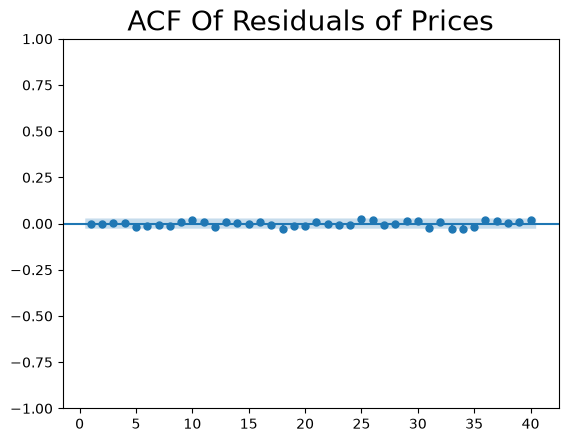

ADF residuos ARMA(6,2) precios: (-76.10853711321703, 0.0, 0, 5020, {'1%': np.float64(-3.431653316130827), '5%': np.float64(-2.8621159253018247), '10%': np.float64(-2.5670765656497516)}, np.float64(54840.30226787091))


In [12]:
df['res_ar_6_ma_2_p'] = results_ar_6_ma_2_p.resid
sgt.plot_acf(df.res_ar_6_ma_2_p, zero=False, lags=40)
plt.title("ACF Of Residuals of Prices", size=20)
plt.show()
print("ADF residuos ARMA(6,2) precios:", sts.adfuller(df.res_ar_6_ma_2_p))